## Regularization penalizes models for overfitting by adding a “penalty term” to the loss function. The two most commonly used ways of doing this are known as Lasso (or L1) and Ridge (or L2) regularization.

Both of these rely on penalizing overfitting by controlling how large the coefficients can get in the first place. The penalty term or regularization term is multiplied by a factor alpha and added to the old loss function as follows:

New loss function
=
Old loss function
+
α
∗
Regularization term
New loss function=Old loss function+α∗Regularization term

Remember that the reason we’re regularizing is because our model is overfitted to our data (i.e., it is performing well on training data but doesn’t generalize well on test data).

The regularization term is the sum of the absolute values of the coefficients in the case of L1 regularization and the sum of the squares of the coefficients in the case of L2.

L1 Regularization term: 
∣
b
1
∣
+
∣
b
2
∣
L1 Regularization term: ∣b 
1
​
 ∣+∣b 
2
​
 ∣
L2 Regularization term: 
b
1
^
2
+
b
2
^
2

​
 
In mathematics, the sum of the magnitudes of a vector is known as its L1 norm (related to “Manhattan distance”) and the square root of the sum of the magnitudes (or the “Euclidean distance” from the origin) is known as its L2 norm - and that is the reason for the names of both methods!

## L1 or Lasso Regularization

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso

In [9]:
# Load dataset
df = pd.read_csv("students_maths.csv")
print(df.info())
y = df['Final_Grade']
X = df.drop(columns=['Final_Grade'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 42 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   age                395 non-null    int64
 1   Medu               395 non-null    int64
 2   Fedu               395 non-null    int64
 3   traveltime         395 non-null    int64
 4   studytime          395 non-null    int64
 5   failures           395 non-null    int64
 6   famrel             395 non-null    int64
 7   freetime           395 non-null    int64
 8   goout              395 non-null    int64
 9   Dalc               395 non-null    int64
 10  Walc               395 non-null    int64
 11  health             395 non-null    int64
 12  absences           395 non-null    int64
 13  G1                 395 non-null    int64
 14  G2                 395 non-null    int64
 15  Final_Grade        395 non-null    int64
 16  school_MS          395 non-null    int64
 17  sex_M              395 non-

In [7]:
# Lasso regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

# Training error
l1_pred_train = lasso.predict(X_train)
l1_mse_train = np.mean((l1_pred_train - y_train) ** 2)
print("Lasso (L1) Training Error:", l1_mse_train)

# Testing error
l1_pred_test = lasso.predict(X_test)
l1_mse_test = np.mean((l1_pred_test - y_test) ** 2)
print("Lasso (L1) Testing Error:", l1_mse_test)

Lasso (L1) Training Error: 3.0118464559476834
Lasso (L1) Testing Error: 4.272174214435374


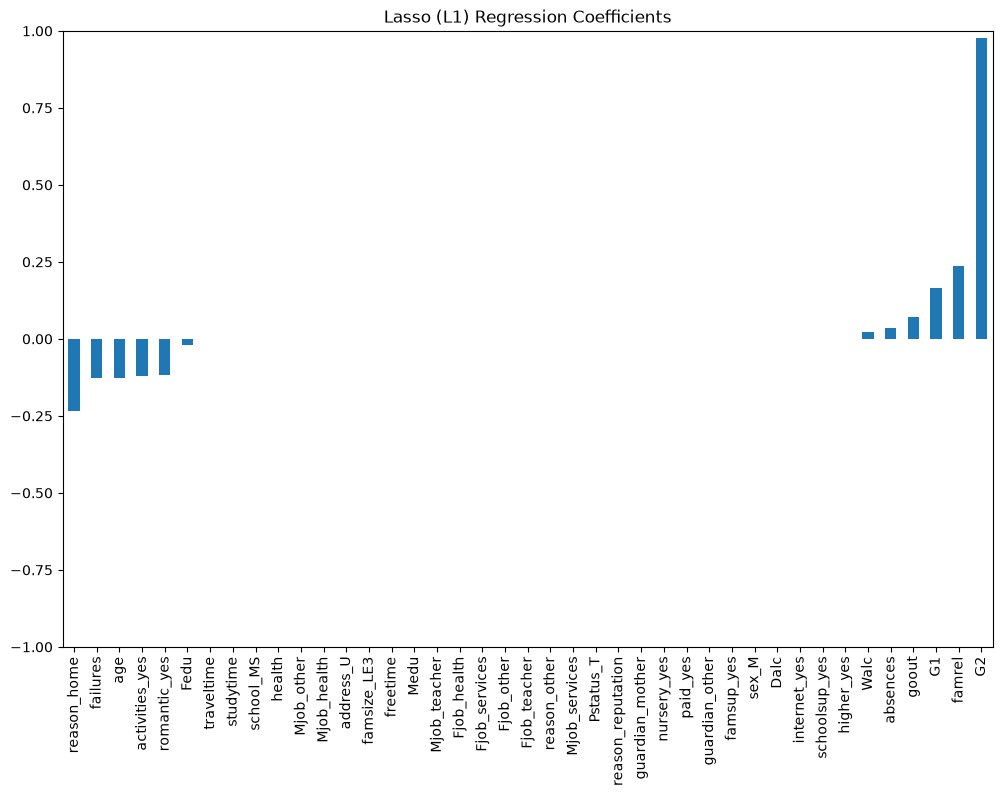

In [10]:
# Coefficient plot
predictors = X.columns
coef = pd.Series(lasso.coef_, index=predictors).sort_values()
plt.figure(figsize=(12, 8))
plt.ylim(-1.0, 1.0)
coef.plot(kind='bar', title='Lasso (L1) Regression Coefficients')
plt.show()

## L2 or Ridge Regularization

In [13]:
from sklearn.linear_model import Ridge
# Ridge regression
ridge = Ridge(alpha=100)
ridge.fit(X_train, y_train)

# Training error
l2_pred_train = ridge.predict(X_train)
l2_mse_train = np.mean((l2_pred_train - y_train) ** 2)
print("Ridge (L2) Training Error:", l2_mse_train)

# Testing error
l2_pred_test = ridge.predict(X_test)
l2_mse_test = np.mean((l2_pred_test - y_test) ** 2)
print("Ridge (L2) Testing Error:", l2_mse_test)


Ridge (L2) Training Error: 2.8476069326177877
Ridge (L2) Testing Error: 4.35738634031129


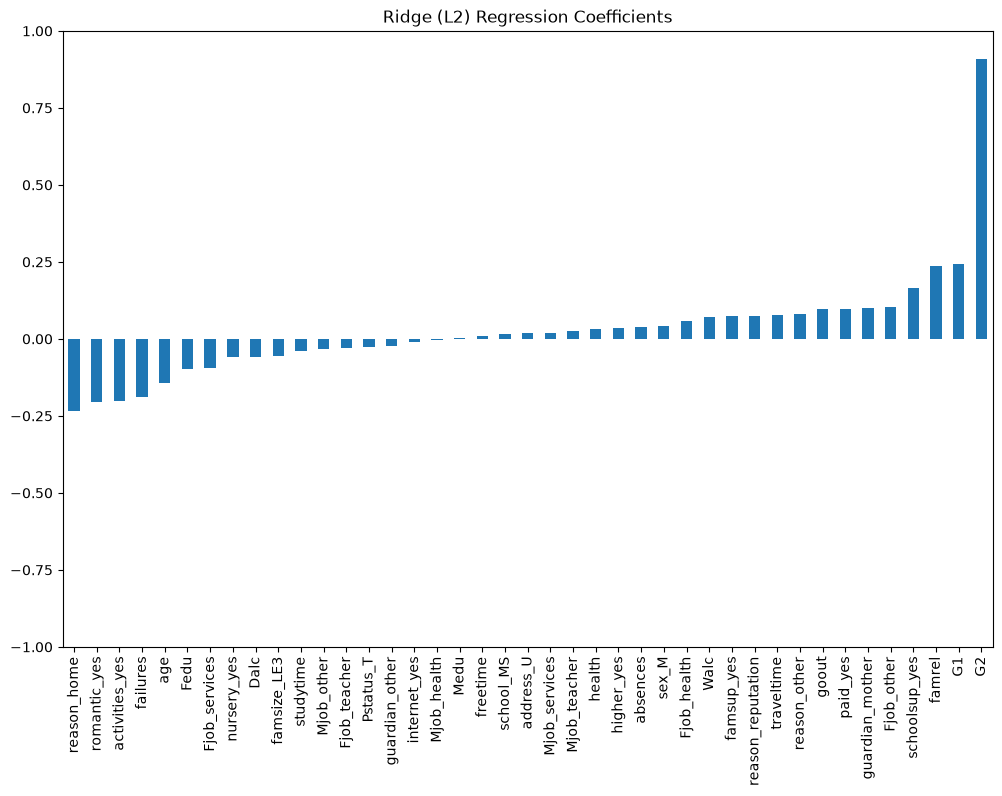

In [14]:
# Coefficient plot
predictors = X.columns
coef = pd.Series(ridge.coef_, index=predictors).sort_values()
plt.figure(figsize=(12, 8))
plt.ylim(-1.0, 1.0)
coef.plot(kind='bar', title='Ridge (L2) Regression Coefficients')
plt.show()